# Reverse Process Test

In [2]:
import sys, importlib, os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils
from typing import Tuple
import yaml
from pathlib import Path
from datetime import datetime
import numpy as np

# Parameters to set

In [17]:
# Set the following parameters
sde_type = "ve"
num_steps = 2000
batch_size = 1
VAE_SCALE_FACTOR = 0.18215

cfg = {
    "sde_type": sde_type,
    "N": num_steps, 
    "vae_scale_factor" : VAE_SCALE_FACTOR
}

In [4]:
# Importing project packages
cwd = Path(os.getcwd())
root_dir = cwd.parent

utils_dir = root_dir.joinpath('src','utils')
weights_dir = root_dir.joinpath('checkpoints','weights')
model_dir = root_dir.joinpath('src','model')
yaml_file_path = root_dir.joinpath('experiments','base_config.yaml')


# Making packages importable
sys.path.append(str(root_dir))

In [5]:
weights_name = 'LDM_final_T2000_LR0001_E50_SA_ts20251211_174407.pth' 

In [6]:
from src.utils import WIP_SDE, WIP_processes
from src.models import unet_model, components
from src.models import unet_model


importlib.reload(WIP_SDE)
importlib.reload(WIP_processes)
importlib.reload(components)
importlib.reload(unet_model)

UNet = unet_model.UNet
from src.utils.WIP_SDE import VESDE, SubVPSDE
from src.utils.WIP_processes import Diffusion_Processes
from src.models.components import SinusoidalPositionEmbeddings # Required by unet_model
#from src.models.unet_model import UNet


In [7]:
diffusion = Diffusion_Processes(cfg)
diffusion.sde_type

've'

In [ ]:
from diffusers import UNet2DModel
model = UNet2DModel.from_pretrained("google/ncsnpp-celebahq-256")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)
model.eval()


In [ ]:
from diffusers import DiffusionPipeline
model_id = "google/ncsnpp-ffhq-256"
# load model and scheduler
sde_ve = DiffusionPipeline.from_pretrained(model_id).to(device)
# run pipeline in inference (sample random noise and denoise)
#model = sde_ve.score_model.to("cuda")
model = sde_ve.unet



# Weights to test (Our Model)

In [8]:
weights_name = "LDM_final_T1000_LR00001_E50_SA_ts20251209_201600.pth"

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the REAL Unet model from unet_model.py
print("Instantiating UNet model...")
model = UNet().to(device)


Using device: cuda
Instantiating UNet model...


In [11]:
def _extract_state_dict(ckpt):
    for k in ("state_dict", "model", "ema", "model_state_dict"):
        if isinstance(ckpt, dict) and k in ckpt and isinstance(ckpt[k], dict):
            return ckpt[k]
    return ckpt

def _strip_prefixes(sd: dict) -> dict:
    if any(k.startswith("module.") for k in sd):
        sd = {k.split("module.", 1)[1] if k.startswith("module.") else k: v for k, v in sd.items()}
    if all(k.startswith("unet.") for k in sd):
        sd = {k[len("unet."):]: v for k, v in sd.items()}
    return sd

def load_model_from_local(model: nn.Module, ckpt_path: str, device: torch.device) -> bool:
    """Load checkpoint from local filesystem instead of Google Drive."""
    if not os.path.isfile(ckpt_path):
        print(f"Error: Checkpoint not found at {ckpt_path}")
        return False
    print(f"Loading model weights from {ckpt_path} ...")

    try:
        ckpt = torch.load(ckpt_path, map_location="cpu")
    except Exception as e:
        print(f"[torch.load] failed: {e}")
        return False

    sd = _extract_state_dict(ckpt)
    sd = _strip_prefixes(sd)

    model_keys = set(model.state_dict().keys())
    filtered = {k: v for k, v in sd.items() if k in model_keys}

    dropped = sorted(k for k in sd.keys() if k not in model_keys)
    if dropped:
        print(f"Dropping {len(dropped)} unexpected keys (showing up to 8):")
        for k in dropped[:8]:
            print("  ", k)
        if len(dropped) > 8:
            print("  ...")

    res = model.load_state_dict(filtered, strict=False)
    print(f"Loaded. missing={len(res.missing_keys)} unexpected={len(res.unexpected_keys)}")

    model.to(device).eval()
    return True

In [14]:
# --- 3. Load Weights ---
ckpt_path = weights_dir.joinpath(weights_name)
load_model_from_local(model, ckpt_path, device)
ckpt_path

Loading model weights from c:\Users\marco\Desktop\Magistrale\ERASMUS\COURSES TUM\Practicals\Hands on Generative AI\Project\Hands-on-Generative-AI\checkpoints\weights\LDM_final_T1000_LR00001_E50_SA_ts20251209_201600.pth ...
Loaded. missing=0 unexpected=0


WindowsPath('c:/Users/marco/Desktop/Magistrale/ERASMUS/COURSES TUM/Practicals/Hands on Generative AI/Project/Hands-on-Generative-AI/checkpoints/weights/LDM_final_T1000_LR00001_E50_SA_ts20251209_201600.pth')

In [16]:
# 2. Define the Wrapper (Fixes the TypeError)
def model_fn(x, t):
    # Diffusers expects t to be shape (B,) or a scalar, usually handles it fine.
    with torch.no_grad():
        out = model(x, t)
            
    # Extract the actual tensor from the output object
    if hasattr(out, 'sample'):
        return out.sample
    return out[0]


In [19]:
from diffusers import AutoencoderKL
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(next(model.parameters()).device).eval()
VAE_SCALE_FACTOR = cfg['vae_scale_factor']
VAE_SCALE_FACTOR

0.18215

In [20]:


def decode_from_latent(latents: torch.Tensor):
    """Converte latenti in pixel [0, 1]."""
    latents = latents / VAE_SCALE_FACTOR
    with torch.no_grad():
        image = vae.decode(latents).sample
    return (image / 2 + 0.5).clamp(0, 1)

[reverse step 1800/2000 | i=1800 | t=0.9000]
mean=-1.2266, std=98.5085, min=-372.4676, max=359.9262
Time of last 200 steps: 2.019097328186035. Time remaining 40.3819465637207.



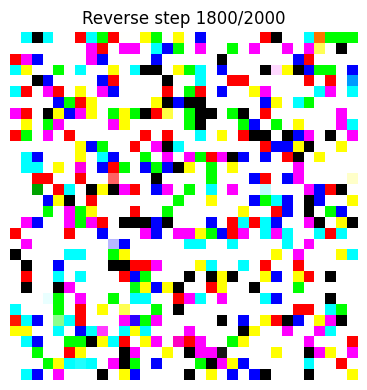

[reverse step 1600/2000 | i=1600 | t=0.8000]
mean=-1.8781, std=115.4156, min=-423.6945, max=423.4254
Time of last 200 steps: 1.903630256652832. Time remaining 76.14521026611328.



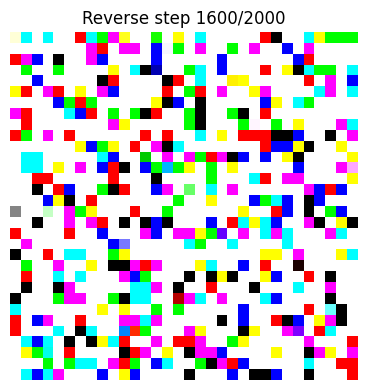

[reverse step 1400/2000 | i=1400 | t=0.7000]
mean=-2.3499, std=122.2227, min=-452.0526, max=437.3226
Time of last 200 steps: 1.7577288150787354. Time remaining 105.46372890472412.



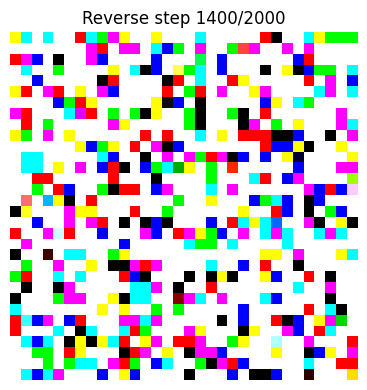

[reverse step 1200/2000 | i=1200 | t=0.6000]
mean=-2.3355, std=125.0894, min=-457.8896, max=441.0151
Time of last 200 steps: 1.7746431827545166. Time remaining 141.97145462036133.



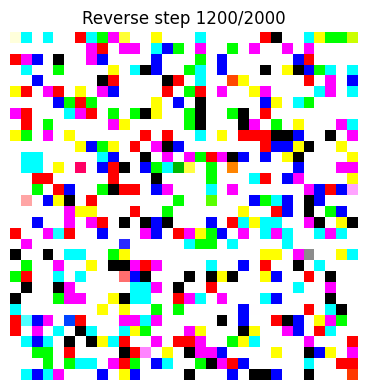

[reverse step 1000/2000 | i=1000 | t=0.5000]
mean=-2.3885, std=126.2682, min=-462.6705, max=444.6143
Time of last 200 steps: 1.9273288249969482. Time remaining 192.73288249969482.



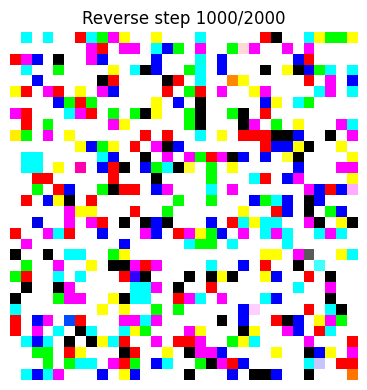

[reverse step 800/2000 | i=800 | t=0.4000]
mean=-2.4051, std=126.7758, min=-465.0310, max=447.2308
Time of last 200 steps: 1.9169743061065674. Time remaining 230.0369167327881.



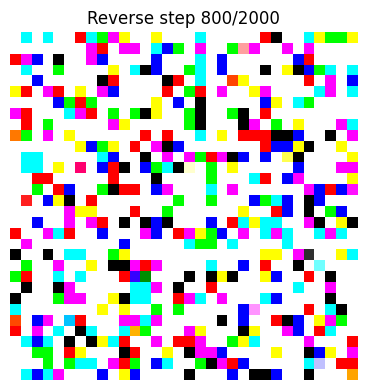

[reverse step 600/2000 | i=600 | t=0.3000]
mean=-2.4040, std=126.9962, min=-465.6852, max=448.4158
Time of last 200 steps: 1.887472152709961. Time remaining 264.24610137939453.



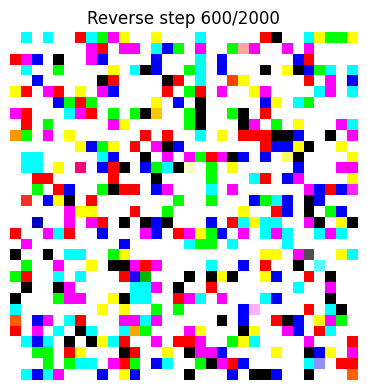

[reverse step 400/2000 | i=400 | t=0.2000]
mean=-2.4083, std=127.0875, min=-466.1102, max=448.6455
Time of last 200 steps: 1.8288543224334717. Time remaining 292.61669158935547.



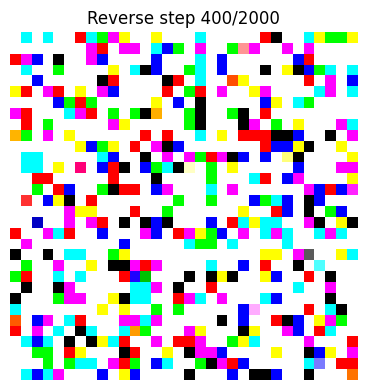

[reverse step 200/2000 | i=200 | t=0.1000]
mean=-2.4107, std=127.1264, min=-466.3194, max=448.7745
Time of last 200 steps: 1.705073356628418. Time remaining 306.91320419311523.



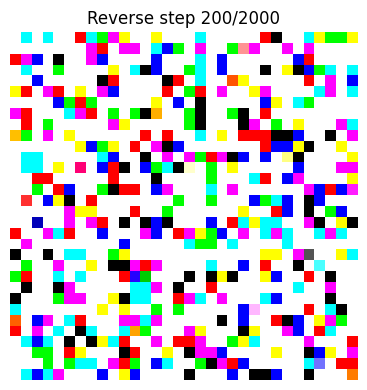

[reverse step 3/2000 | i=3 | t=0.0015]
mean=-2.4110, std=127.1429, min=-466.3985, max=448.8410
Time of last 200 steps: 2.0482137203216553. Time remaining 409.64274406433105.



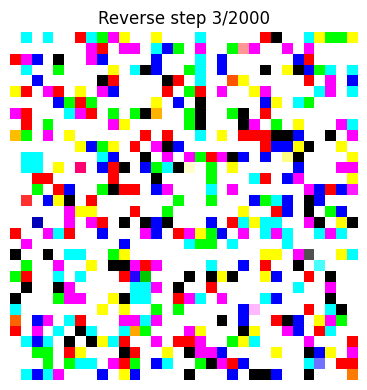

In [22]:
# 3. Run Sampling (Fixes the AttributeError via the class update)
samples = diffusion.reverse_process(
    model=model_fn,              # Pass the wrapper!
    shape=(batch_size, 4, 32, 32),
    num_steps=cfg.get('N', 1000),
    probability_flow=False,
    device=device                # Pass device explicitly
)

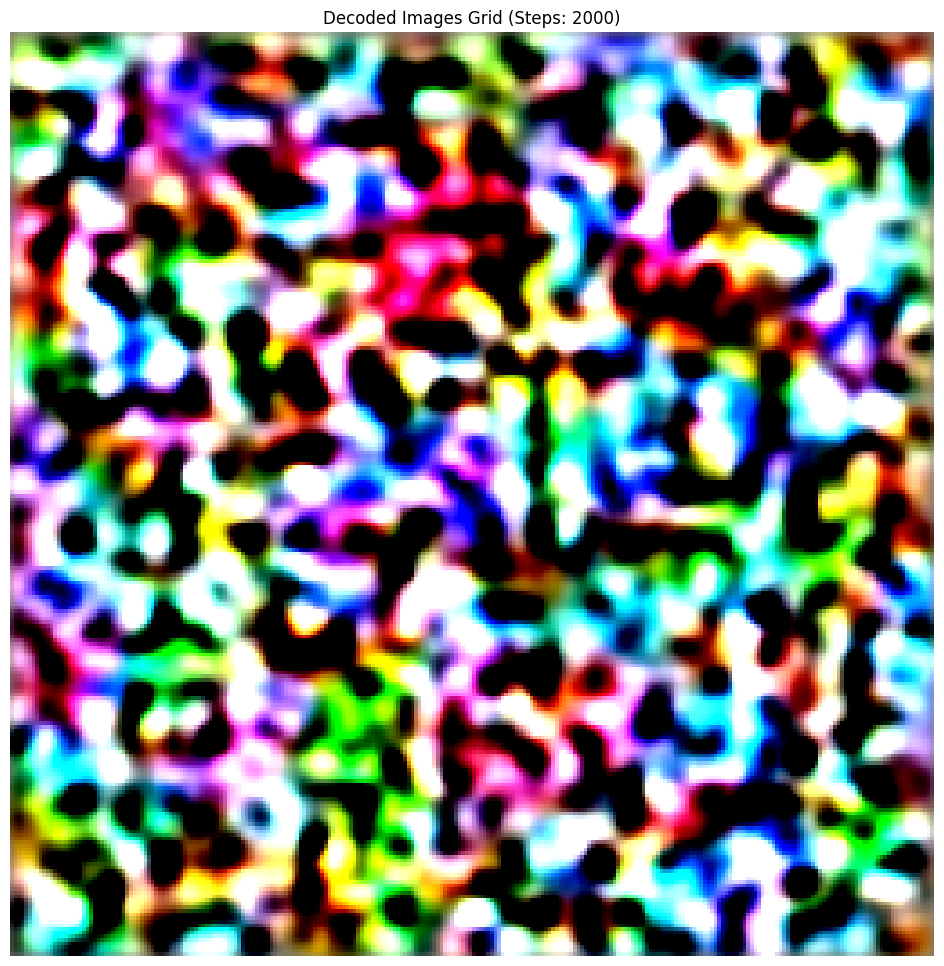

In [23]:
decoded_images = []

# --- 1. Decodifica tutte le immagini e salva in una lista ---
for latent in samples:
    latent = latent.to(next(vae.parameters()).device, dtype=torch.float32).unsqueeze(0)
    decoded = decode_from_latent(latent)  # [1, C, H, W]
    decoded_images.append(decoded[0])      # Rimuovi dimensione batch

# --- 2. Crea un batch da lista di tensori ---
decoded_batch = torch.stack(decoded_images)  # [B, C, H, W]
# --- 3. Crea griglia ---
grid = torchvision.utils.make_grid(decoded_batch, nrow=4, normalize=True, value_range=(0, 1))

# --- 4. Visualizza e salva ---
plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0).cpu())  # [H, W, C]
plt.axis("off")
plt.title(f"Decoded Images Grid (Steps: {cfg['N']})")

# Salva la griglia
plt.show()


Sample stats: Min=-466.40, Max=448.84, Mean=-2.41


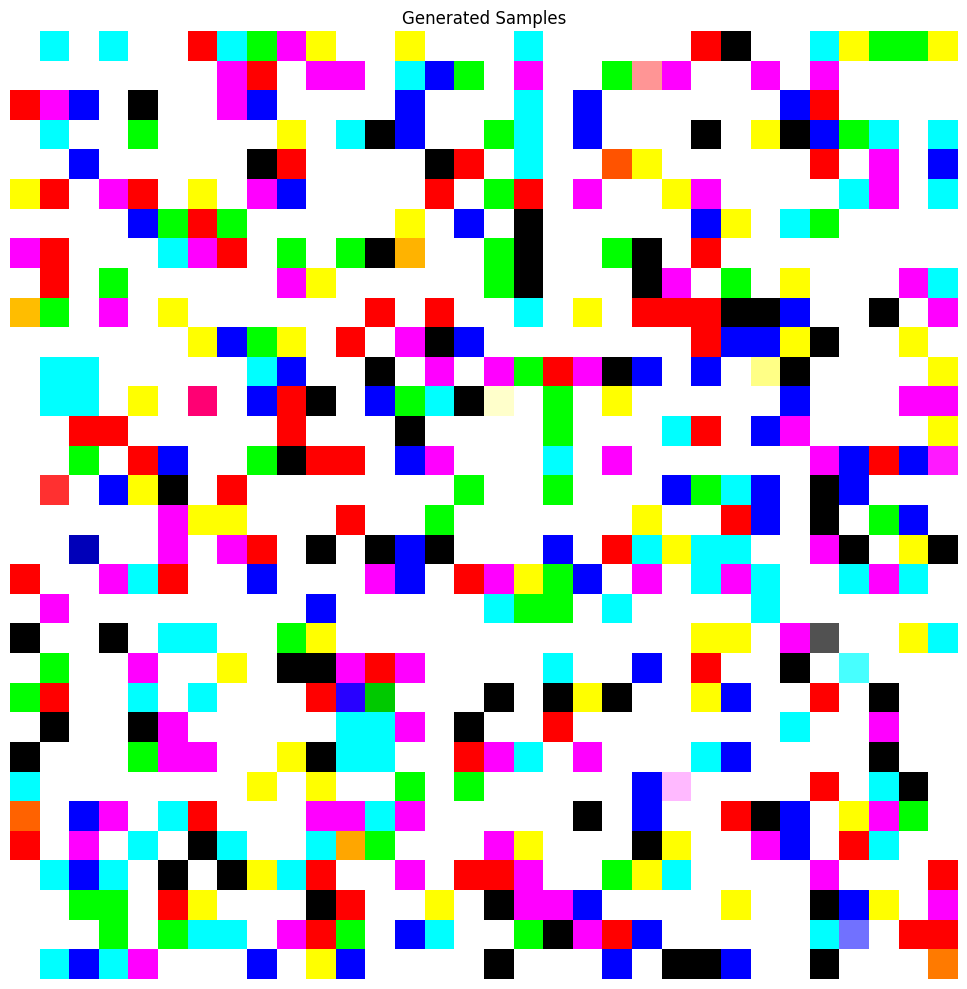

In [24]:
def show_samples(samples):
    # 1. Ensure we are on CPU
    samples_vis = samples.detach().cpu()
    
    # 2. Inspect statistics (Crucial for debugging!)
    print(f"Sample stats: Min={samples_vis.min():.2f}, Max={samples_vis.max():.2f}, Mean={samples_vis.mean():.2f}")
    
    # 3. Robust Normalization
    # SDE models often output values outside [-1, 1] before the final step.
    # If strict [-1, 1] is expected:
    samples_vis = samples_vis.clamp(-1.0, 1.0)
    samples_vis = (samples_vis + 1.0) / 2.0
    
    # 4. Create Grid
    # nrow=int(np.sqrt(batch_size)) automatically makes a square grid
    grid = torchvision.utils.make_grid(samples_vis, nrow=int(np.sqrt(samples_vis.shape[0])), padding=2)
    
    # 5. Permute for Matplotlib
    np_grid = grid.permute(1, 2, 0).numpy()
    
    # 6. Plot
    plt.figure(figsize=(10, 10))
    plt.imshow(np_grid)
    plt.axis("off")
    plt.title("Generated Samples")
    plt.tight_layout()
    plt.show()

# Run the visualization
show_samples(samples)